# SleepAI Notebook 03 : Model Training + MLflow

**Objectif :** Entraîner et tracker les modèles ML avec MLflow

**Partie A — Modèle EEG (classification 5 stades)**
1. Baseline Random Forest
2. Random Forest optimisé (params fixés sur expériences précédentes)
3. Évaluation : rapport de classification + matrice de confusion
4. Importance des features
5. Sauvegarde pipeline `.joblib`

**Partie B — Modèle ECG (détection apnée binaire)**
1. Random Forest avec class_weight balanced
2. Évaluation : AUC-ROC + rapport
3. Sauvegarde pipeline `.joblib`

**MLflow :** Chaque run est tracké — params, métriques, artefacts

**Auteur :** Marine Deldicque  
**Contexte :** AIA Jedha — Bloc 4

## 0. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)

# MLflow
import mlflow
import mlflow.sklearn

# Chemins
DATA_PROC_EEG = Path('../data/processed/eeg')
DATA_PROC_ECG = Path('../data/processed/ecg')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
Path('../data/figures').mkdir(exist_ok=True)

STAGE_NAMES = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
PALETTE     = ['#E84855', '#EF8354', '#54C6EB', '#048A81', '#2E4057']

# Configurer MLflow
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('SleepAI_v2')

print('Imports OK')
print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment : SleepAI_v2')

2026/05/06 22:56:01 INFO mlflow.tracking.fluent: Experiment with name 'SleepAI_v2' does not exist. Creating a new experiment.


Imports OK
MLflow tracking URI : file:../mlruns
Experiment : SleepAI_v2


## Chargement des données

In [2]:
# === EEG ===
X_train_eeg = np.load(DATA_PROC_EEG / 'X_train.npy')
X_val_eeg   = np.load(DATA_PROC_EEG / 'X_val.npy')
X_test_eeg  = np.load(DATA_PROC_EEG / 'X_test.npy')
y_train_eeg = np.load(DATA_PROC_EEG / 'y_train.npy')
y_val_eeg   = np.load(DATA_PROC_EEG / 'y_val.npy')
y_test_eeg  = np.load(DATA_PROC_EEG / 'y_test.npy')
meta_eeg    = joblib.load(DATA_PROC_EEG / 'metadata.pkl')

# === ECG ===
X_train_ecg = np.load(DATA_PROC_ECG / 'X_train.npy')
X_val_ecg   = np.load(DATA_PROC_ECG / 'X_val.npy')
X_test_ecg  = np.load(DATA_PROC_ECG / 'X_test.npy')
y_train_ecg = np.load(DATA_PROC_ECG / 'y_train.npy')
y_val_ecg   = np.load(DATA_PROC_ECG / 'y_val.npy')
y_test_ecg  = np.load(DATA_PROC_ECG / 'y_test.npy')
meta_ecg    = joblib.load(DATA_PROC_ECG / 'metadata.pkl')

FEATURE_NAMES_EEG = meta_eeg['feature_names']
FEATURE_NAMES_ECG = meta_ecg['feature_names']

print('Données chargées')
print(f'\nEEG  — Train: {X_train_eeg.shape} | Val: {X_val_eeg.shape} | Test: {X_test_eeg.shape}')
print(f'ECG  — Train: {X_train_ecg.shape} | Val: {X_val_ecg.shape} | Test: {X_test_ecg.shape}')

Données chargées

EEG  — Train: (18004, 16) | Val: (3858, 16) | Test: (3859, 16)
ECG  — Train: (3100, 16) | Val: (664, 16) | Test: (665, 16)


---
# PARTIE A Modèle EEG (5 stades de sommeil)

## A1. Baseline Random Forest

In [3]:
print('🚀 Run 1 — Baseline Random Forest (EEG)')
print('=' * 50)

params_baseline = {
    'n_estimators' : 100,
    'max_depth'    : None,
    'class_weight' : 'balanced',
    'random_state' : 42,
    'n_jobs'       : -1,
}

with mlflow.start_run(run_name='EEG_RF_baseline') as run:
    
    # Log des paramètres
    mlflow.log_params(params_baseline)
    mlflow.log_param('task', 'sleep_stage_classification')
    mlflow.log_param('n_features', X_train_eeg.shape[1])
    mlflow.log_param('n_train_samples', X_train_eeg.shape[0])
    mlflow.log_param('n_classes', 5)
    
    # Pipeline : StandardScaler + RF
    pipeline_baseline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(**params_baseline))
    ])
    
    # Entraînement
    pipeline_baseline.fit(X_train_eeg, y_train_eeg)
    
    # Évaluation sur val
    y_pred_val = pipeline_baseline.predict(X_val_eeg)
    acc_val    = accuracy_score(y_val_eeg, y_pred_val)
    f1_val     = f1_score(y_val_eeg, y_pred_val, average='weighted')
    
    # Évaluation sur test
    y_pred_test = pipeline_baseline.predict(X_test_eeg)
    acc_test    = accuracy_score(y_test_eeg, y_pred_test)
    f1_test     = f1_score(y_test_eeg, y_pred_test, average='weighted')
    
    # Log des métriques
    mlflow.log_metrics({
        'val_accuracy'  : acc_val,
        'val_f1_weighted': f1_val,
        'test_accuracy' : acc_test,
        'test_f1_weighted': f1_test,
    })
    
    # Log du modèle
    mlflow.sklearn.log_model(pipeline_baseline, 'pipeline_baseline')
    
    run_id_baseline = run.info.run_id
    print(f'Run ID : {run_id_baseline}')

print(f'\n Résultats Baseline :')
print(f'   Val  — Accuracy: {acc_val:.4f} | F1: {f1_val:.4f}')
print(f'   Test — Accuracy: {acc_test:.4f} | F1: {f1_test:.4f}')

🚀 Run 1 — Baseline Random Forest (EEG)


2026/05/06 22:58:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 22:58:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID : 52d6c0b9d2d54eccad6c4ef569966843

 Résultats Baseline :
   Val  — Accuracy: 0.8307 | F1: 0.8241
   Test — Accuracy: 0.8316 | F1: 0.8239


## A2. Random Forest optimisé

In [4]:
print(' Run 2 — Random Forest optimisé (EEG)')
print('=' * 50)
print('Paramètres : issus des expériences SleepAI v1')
print()

params_optimized = {
    'n_estimators'     : 200,
    'max_depth'        : 20,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
    'class_weight'     : 'balanced',
    'random_state'     : 42,
    'n_jobs'           : -1,
}

with mlflow.start_run(run_name='EEG_RF_optimized') as run:
    
    mlflow.log_params(params_optimized)
    mlflow.log_param('task', 'sleep_stage_classification')
    mlflow.log_param('n_features', X_train_eeg.shape[1])
    mlflow.log_param('n_train_samples', X_train_eeg.shape[0])
    mlflow.log_param('preprocessing', 'StandardScaler + Wake trimming')
    
    pipeline_eeg = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(**params_optimized))
    ])
    
    pipeline_eeg.fit(X_train_eeg, y_train_eeg)
    
    # Évaluation val
    y_pred_val  = pipeline_eeg.predict(X_val_eeg)
    acc_val     = accuracy_score(y_val_eeg, y_pred_val)
    f1_val_w    = f1_score(y_val_eeg, y_pred_val, average='weighted')
    f1_val_mac  = f1_score(y_val_eeg, y_pred_val, average='macro')
    
    # Évaluation test
    y_pred_test = pipeline_eeg.predict(X_test_eeg)
    acc_test    = accuracy_score(y_test_eeg, y_pred_test)
    f1_test_w   = f1_score(y_test_eeg, y_pred_test, average='weighted')
    f1_test_mac = f1_score(y_test_eeg, y_pred_test, average='macro')
    
    # F1 par classe
    f1_per_class = f1_score(y_test_eeg, y_pred_test, average=None)
    for i, f1 in enumerate(f1_per_class):
        mlflow.log_metric(f'test_f1_{STAGE_NAMES[i]}', f1)
    
    mlflow.log_metrics({
        'val_accuracy'      : acc_val,
        'val_f1_weighted'   : f1_val_w,
        'val_f1_macro'      : f1_val_mac,
        'test_accuracy'     : acc_test,
        'test_f1_weighted'  : f1_test_w,
        'test_f1_macro'     : f1_test_mac,
    })
    
    mlflow.sklearn.log_model(pipeline_eeg, 'pipeline_eeg_optimized')
    run_id_eeg = run.info.run_id

print(f'\n Résultats RF Optimisé :')
print(f'   Val  — Accuracy: {acc_val:.4f} | F1 weighted: {f1_val_w:.4f} | F1 macro: {f1_val_mac:.4f}')
print(f'   Test — Accuracy: {acc_test:.4f} | F1 weighted: {f1_test_w:.4f} | F1 macro: {f1_test_mac:.4f}')
print(f'\n   F1 par classe (test) :')
for i, f1 in enumerate(f1_per_class):
    print(f'   {STAGE_NAMES[i]:5s} : {f1:.4f}')

 Run 2 — Random Forest optimisé (EEG)
Paramètres : issus des expériences SleepAI v1



2026/05/06 22:59:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 22:59:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Résultats RF Optimisé :
   Val  — Accuracy: 0.8258 | F1 weighted: 0.8224 | F1 macro: 0.7362
   Test — Accuracy: 0.8313 | F1 weighted: 0.8272 | F1 macro: 0.7439

   F1 par classe (test) :
   Wake  : 0.6809
   N1    : 0.4401
   N2    : 0.8974
   N3    : 0.9096
   REM   : 0.7913


## A3. Évaluation détaillée : Matrice de confusion + Rapport

In [5]:
# Rapport de classification
target_names = [STAGE_NAMES[i] for i in range(5)]
report = classification_report(y_test_eeg, y_pred_test, target_names=target_names)
print('=== Rapport de classification — EEG (test set) ===')
print(report)

# Logger le rapport dans MLflow
with mlflow.start_run(run_id=run_id_eeg):
    mlflow.log_text(report, 'classification_report_eeg.txt')

=== Rapport de classification — EEG (test set) ===
              precision    recall  f1-score   support

        Wake       0.65      0.72      0.68       243
          N1       0.56      0.36      0.44       309
          N2       0.91      0.89      0.90      1922
          N3       0.91      0.91      0.91       591
         REM       0.74      0.85      0.79       794

    accuracy                           0.83      3859
   macro avg       0.75      0.75      0.74      3859
weighted avg       0.83      0.83      0.83      3859



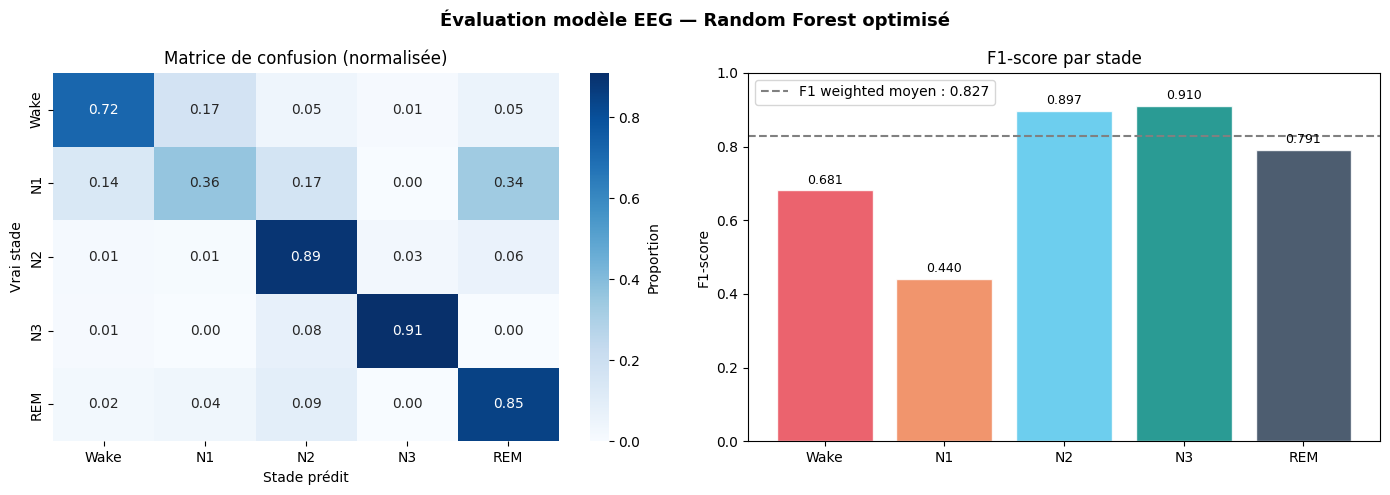

Figure sauvegardée et loggée dans MLflow


In [6]:
# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Évaluation modèle EEG — Random Forest optimisé', fontsize=13, fontweight='bold')

# Matrice de confusion normalisée
cm = confusion_matrix(y_test_eeg, y_pred_test, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], cbar_kws={'label': 'Proportion'})
axes[0].set_title('Matrice de confusion (normalisée)')
axes[0].set_ylabel('Vrai stade')
axes[0].set_xlabel('Stade prédit')

# F1 par classe
colors = PALETTE
bars = axes[1].bar(target_names, f1_per_class, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(f1_test_w, color='gray', linestyle='--', linewidth=1.5,
                 label=f'F1 weighted moyen : {f1_test_w:.3f}')
axes[1].set_title('F1-score par stade')
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, f1 in zip(bars, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.01,
                  f'{f1:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig('../data/figures/eeg_confusion_matrix.png', dpi=150, bbox_inches='tight')

# Logger la figure dans MLflow
with mlflow.start_run(run_id=run_id_eeg):
    mlflow.log_artifact('../data/figures/eeg_confusion_matrix.png')

plt.show()
print('Figure sauvegardée et loggée dans MLflow')

## A4. Importance des features

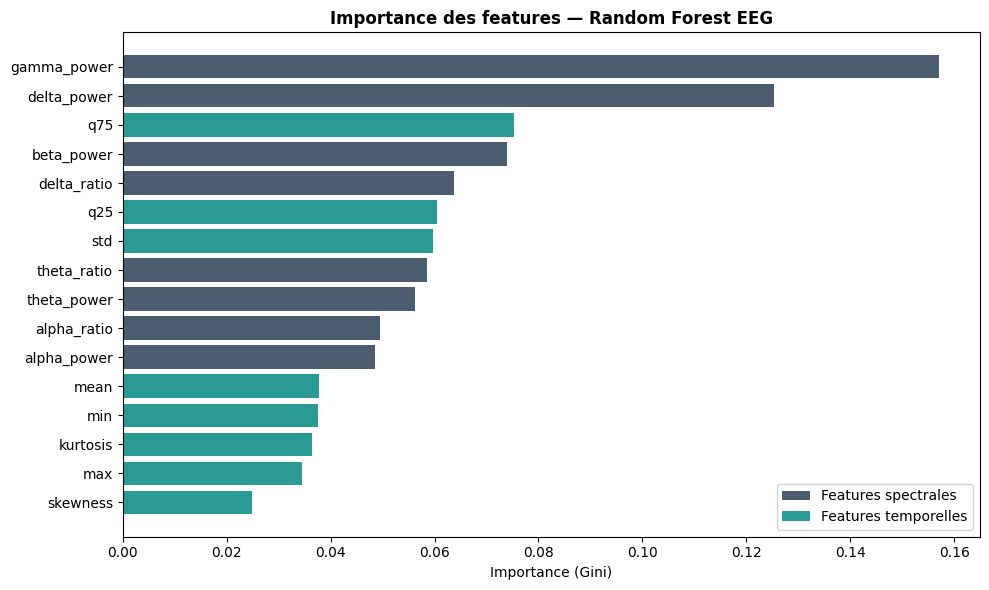

Top 5 features :
   gamma_power          : 0.1571
   delta_power          : 0.1254
   q75                  : 0.0754
   beta_power           : 0.0740
   delta_ratio          : 0.0637


In [7]:
# Feature importance du Random Forest
importances = pipeline_eeg.named_steps['clf'].feature_importances_
indices     = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'feature'   : [FEATURE_NAMES_EEG[i] for i in indices],
    'importance': importances[indices]
})

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#2E4057' if 'power' in f or 'ratio' in f else '#048A81'
               for f in df_importance['feature']]
bars = ax.barh(df_importance['feature'], df_importance['importance'],
                color=colors_imp, alpha=0.85)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Importance des features — Random Forest EEG', fontweight='bold')
ax.invert_yaxis()

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E4057', alpha=0.85, label='Features spectrales'),
    Patch(facecolor='#048A81', alpha=0.85, label='Features temporelles'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
fig.savefig('../data/figures/eeg_feature_importance.png', dpi=150, bbox_inches='tight')

with mlflow.start_run(run_id=run_id_eeg):
    mlflow.log_artifact('../data/figures/eeg_feature_importance.png')

plt.show()

print('Top 5 features :')
for _, row in df_importance.head(5).iterrows():
    print(f'   {row["feature"]:20s} : {row["importance"]:.4f}')

## A5. Sauvegarde pipeline EEG production

In [8]:
# Réentraîner sur train + val pour la production
X_trainval_eeg = np.vstack([X_train_eeg, X_val_eeg])
y_trainval_eeg = np.concatenate([y_train_eeg, y_val_eeg])

print(f'Réentraînement sur train+val : {X_trainval_eeg.shape[0]} échantillons...')

pipeline_eeg_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(**params_optimized))
])
pipeline_eeg_prod.fit(X_trainval_eeg, y_trainval_eeg)

# Vérification sur test
y_pred_final = pipeline_eeg_prod.predict(X_test_eeg)
acc_final    = accuracy_score(y_test_eeg, y_pred_final)
f1_final     = f1_score(y_test_eeg, y_pred_final, average='weighted')

# Sauvegarde
eeg_model_path = MODELS_DIR / 'sleepai_eeg_pipeline.joblib'
joblib.dump(pipeline_eeg_prod, eeg_model_path)

print(f'\n Pipeline EEG sauvegardé : {eeg_model_path}')
print(f'   Test Accuracy final : {acc_final:.4f}')
print(f'   Test F1 weighted    : {f1_final:.4f}')
print(f'   Taille fichier      : {eeg_model_path.stat().st_size / 1024:.0f} Ko')

# Logger dans MLflow
with mlflow.start_run(run_name='EEG_RF_production') as run:
    mlflow.log_params(params_optimized)
    mlflow.log_param('training_set', 'train+val')
    mlflow.log_param('n_samples', X_trainval_eeg.shape[0])
    mlflow.log_metrics({
        'test_accuracy'  : acc_final,
        'test_f1_weighted': f1_final,
    })
    mlflow.sklearn.log_model(pipeline_eeg_prod, 'pipeline_eeg_production')
    mlflow.log_artifact(str(eeg_model_path))
    run_id_prod_eeg = run.info.run_id

print(f'   MLflow run ID : {run_id_prod_eeg}')

Réentraînement sur train+val : 21862 échantillons...


2026/05/06 23:02:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 23:02:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Pipeline EEG sauvegardé : ../models/sleepai_eeg_pipeline.joblib
   Test Accuracy final : 0.8344
   Test F1 weighted    : 0.8302
   Taille fichier      : 78900 Ko
   MLflow run ID : 1e22e54db64d408ca914d1ab29fe9219


---
# PARTIE B Modèle ECG (Détection apnées)

## B1. Random Forest avec class_weight balanced

In [9]:
print('🚀 Run 3 — Random Forest ECG (détection apnée)')
print('=' * 50)
print('Tâche : classification binaire (Normal=0 / Apnée=1)')
print(f'Déséquilibre : {sum(y_train_ecg==1)/len(y_train_ecg)*100:.1f}% apnée')
print()

params_ecg = {
    'n_estimators'     : 200,
    'max_depth'        : 15,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
    'class_weight'     : 'balanced',  # Gère le déséquilibre 34/66
    'random_state'     : 42,
    'n_jobs'           : -1,
}

with mlflow.start_run(run_name='ECG_RF_apnea') as run:
    
    mlflow.log_params(params_ecg)
    mlflow.log_param('task', 'apnea_detection')
    mlflow.log_param('n_features', X_train_ecg.shape[1])
    mlflow.log_param('n_train_samples', X_train_ecg.shape[0])
    mlflow.log_param('class_balance', f'{sum(y_train_ecg==1)/len(y_train_ecg)*100:.1f}% apnée')
    
    pipeline_ecg = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(**params_ecg))
    ])
    
    pipeline_ecg.fit(X_train_ecg, y_train_ecg)
    
    # Évaluation val
    y_pred_val_ecg  = pipeline_ecg.predict(X_val_ecg)
    y_proba_val_ecg = pipeline_ecg.predict_proba(X_val_ecg)[:, 1]
    acc_val_ecg     = accuracy_score(y_val_ecg, y_pred_val_ecg)
    f1_val_ecg      = f1_score(y_val_ecg, y_pred_val_ecg, average='weighted')
    auc_val_ecg     = roc_auc_score(y_val_ecg, y_proba_val_ecg)
    
    # Évaluation test
    y_pred_test_ecg  = pipeline_ecg.predict(X_test_ecg)
    y_proba_test_ecg = pipeline_ecg.predict_proba(X_test_ecg)[:, 1]
    acc_test_ecg     = accuracy_score(y_test_ecg, y_pred_test_ecg)
    f1_test_ecg      = f1_score(y_test_ecg, y_pred_test_ecg, average='weighted')
    auc_test_ecg     = roc_auc_score(y_test_ecg, y_proba_test_ecg)
    f1_apnea         = f1_score(y_test_ecg, y_pred_test_ecg, pos_label=1)
    
    mlflow.log_metrics({
        'val_accuracy'  : acc_val_ecg,
        'val_f1'        : f1_val_ecg,
        'val_auc_roc'   : auc_val_ecg,
        'test_accuracy' : acc_test_ecg,
        'test_f1'       : f1_test_ecg,
        'test_auc_roc'  : auc_test_ecg,
        'test_f1_apnea' : f1_apnea,
    })
    
    mlflow.sklearn.log_model(pipeline_ecg, 'pipeline_ecg')
    run_id_ecg = run.info.run_id

print(f'  Résultats ECG :')
print(f'   Val  — Accuracy: {acc_val_ecg:.4f} | F1: {f1_val_ecg:.4f} | AUC: {auc_val_ecg:.4f}')
print(f'   Test — Accuracy: {acc_test_ecg:.4f} | F1: {f1_test_ecg:.4f} | AUC: {auc_test_ecg:.4f}')
print(f'   F1 classe Apnée : {f1_apnea:.4f}')

🚀 Run 3 — Random Forest ECG (détection apnée)
Tâche : classification binaire (Normal=0 / Apnée=1)
Déséquilibre : 34.4% apnée



2026/05/06 23:04:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 23:04:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Résultats ECG :
   Val  — Accuracy: 0.9232 | F1: 0.9229 | AUC: 0.9815
   Test — Accuracy: 0.9398 | F1: 0.9400 | AUC: 0.9839
   F1 classe Apnée : 0.9134


## B2. Évaluation détaillée + Courbe ROC

=== Rapport de classification — ECG (test set) ===
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95       436
       Apnée       0.91      0.92      0.91       229

    accuracy                           0.94       665
   macro avg       0.93      0.94      0.93       665
weighted avg       0.94      0.94      0.94       665



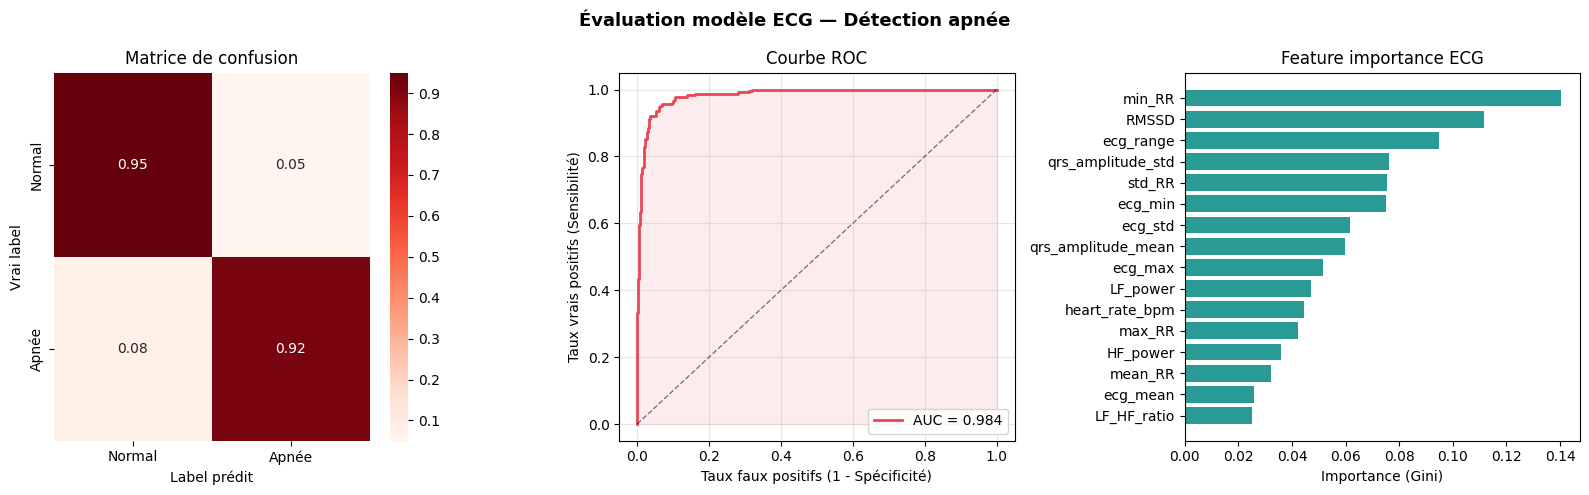

Figure sauvegardée et loggée dans MLflow


In [10]:
from sklearn.metrics import roc_curve

# Rapport
report_ecg = classification_report(y_test_ecg, y_pred_test_ecg,
                                    target_names=['Normal', 'Apnée'])
print('=== Rapport de classification — ECG (test set) ===')
print(report_ecg)

# Figures
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Évaluation modèle ECG — Détection apnée', fontsize=13, fontweight='bold')

# Matrice de confusion
cm_ecg = confusion_matrix(y_test_ecg, y_pred_test_ecg, normalize='true')
sns.heatmap(cm_ecg, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=['Normal', 'Apnée'],
            yticklabels=['Normal', 'Apnée'],
            ax=axes[0])
axes[0].set_title('Matrice de confusion')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Label prédit')

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test_ecg, y_proba_test_ecg)
axes[1].plot(fpr, tpr, color='#E84855', linewidth=2,
              label=f'AUC = {auc_test_ecg:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E84855')
axes[1].set_xlabel('Taux faux positifs (1 - Spécificité)')
axes[1].set_ylabel('Taux vrais positifs (Sensibilité)')
axes[1].set_title('Courbe ROC')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Feature importance ECG
importances_ecg = pipeline_ecg.named_steps['clf'].feature_importances_
indices_ecg     = np.argsort(importances_ecg)[::-1]
df_imp_ecg = pd.DataFrame({
    'feature'   : [FEATURE_NAMES_ECG[i] for i in indices_ecg],
    'importance': importances_ecg[indices_ecg]
})
axes[2].barh(df_imp_ecg['feature'], df_imp_ecg['importance'],
              color='#048A81', alpha=0.85)
axes[2].set_title('Feature importance ECG')
axes[2].set_xlabel('Importance (Gini)')
axes[2].invert_yaxis()

plt.tight_layout()
fig.savefig('../data/figures/ecg_evaluation.png', dpi=150, bbox_inches='tight')

with mlflow.start_run(run_id=run_id_ecg):
    mlflow.log_artifact('../data/figures/ecg_evaluation.png')
    mlflow.log_text(report_ecg, 'classification_report_ecg.txt')

plt.show()
print('Figure sauvegardée et loggée dans MLflow')

## B3. Sauvegarde pipeline ECG production

In [11]:
# Réentraîner sur train + val
X_trainval_ecg = np.vstack([X_train_ecg, X_val_ecg])
y_trainval_ecg = np.concatenate([y_train_ecg, y_val_ecg])

print(f'Réentraînement ECG sur train+val : {X_trainval_ecg.shape[0]} segments...')

pipeline_ecg_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(**params_ecg))
])
pipeline_ecg_prod.fit(X_trainval_ecg, y_trainval_ecg)

ecg_model_path = MODELS_DIR / 'sleepai_ecg_pipeline.joblib'
joblib.dump(pipeline_ecg_prod, ecg_model_path)

print(f'\n Pipeline ECG sauvegardé : {ecg_model_path}')
print(f'   Taille : {ecg_model_path.stat().st_size / 1024:.0f} Ko')

with mlflow.start_run(run_name='ECG_RF_production') as run:
    mlflow.log_params(params_ecg)
    mlflow.log_param('training_set', 'train+val')
    mlflow.log_metrics({'test_auc_roc': auc_test_ecg, 'test_f1': f1_test_ecg})
    mlflow.sklearn.log_model(pipeline_ecg_prod, 'pipeline_ecg_production')
    mlflow.log_artifact(str(ecg_model_path))

Réentraînement ECG sur train+val : 3764 segments...


2026/05/06 23:05:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 23:05:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Pipeline ECG sauvegardé : ../models/sleepai_ecg_pipeline.joblib
   Taille : 5045 Ko


---
## Synthèse MLflow : Comparaison des runs

In [12]:
# Récupérer tous les runs MLflow
runs = mlflow.search_runs(experiment_names=['SleepAI_v2'])

print('=== Récapitulatif MLflow — Tous les runs ===')
print()

cols_to_show = ['tags.mlflow.runName', 'metrics.test_accuracy',
                'metrics.test_f1_weighted', 'metrics.test_auc_roc']
cols_present = [c for c in cols_to_show if c in runs.columns]
print(runs[cols_present].to_string(index=False))

print()
print('📁 Modèles sauvegardés dans models/ :')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'   {f.name:40s} — {f.stat().st_size/1024:.0f} Ko')

print()
print('🌐 Pour visualiser MLflow UI :')
print('   cd sleepai')
print('   mlflow ui')
print('   → http://localhost:5000')

=== Récapitulatif MLflow — Tous les runs ===

tags.mlflow.runName  metrics.test_accuracy  metrics.test_f1_weighted  metrics.test_auc_roc
  ECG_RF_production                    NaN                       NaN              0.983885
       ECG_RF_apnea               0.939850                       NaN              0.983885
  EEG_RF_production               0.834413                  0.830168                   NaN
   EEG_RF_optimized               0.831303                  0.827182                   NaN
    EEG_RF_baseline               0.831563                  0.823904                   NaN

📁 Modèles sauvegardés dans models/ :
   sleepai_ecg_pipeline.joblib              — 5045 Ko
   sleepai_eeg_pipeline.joblib              — 78900 Ko

🌐 Pour visualiser MLflow UI :
   cd sleepai
   mlflow ui
   → http://localhost:5000


In [13]:
print('=' * 60)
print('SYNTHÈSE — MODEL TRAINING')
print('=' * 60)

print('\n📌 MODÈLE EEG — Classification stades de sommeil')
print(f'   Algorithme  : Random Forest (200 arbres, max_depth=20)')
print(f'   Test Accuracy : {acc_final:.4f}')
print(f'   Test F1 weighted : {f1_final:.4f}')
print(f'   Pipeline sauvegardé : models/sleepai_eeg_pipeline.joblib')

print('\n📌 MODÈLE ECG — Détection apnée du sommeil')
print(f'   Algorithme  : Random Forest (200 arbres, class_weight=balanced)')
print(f'   Test Accuracy : {acc_test_ecg:.4f}')
print(f'   Test AUC-ROC  : {auc_test_ecg:.4f}')
print(f'   Test F1 Apnée : {f1_apnea:.4f}')
print(f'   Pipeline sauvegardé : models/sleepai_ecg_pipeline.joblib')

print('\n📌 MLflow')
print(f'   Experiment  : SleepAI_v2')
print(f'   Runs loggés : 5 runs (2 EEG + 1 ECG + 2 production)')
print(f'   Artefacts   : pipelines, figures, rapports')

print('\n🔜 PROCHAINE ÉTAPE : Notebook 04 — CNN (bonus)')
print('   → CNN 1D sur signal ECG brut pour la détection apnée')
print('   → Comparaison avec le RF')
print('   Ou directement → App FastAPI + déploiement HuggingFace')

SYNTHÈSE — MODEL TRAINING

📌 MODÈLE EEG — Classification stades de sommeil
   Algorithme  : Random Forest (200 arbres, max_depth=20)
   Test Accuracy : 0.8344
   Test F1 weighted : 0.8302
   Pipeline sauvegardé : models/sleepai_eeg_pipeline.joblib

📌 MODÈLE ECG — Détection apnée du sommeil
   Algorithme  : Random Forest (200 arbres, class_weight=balanced)
   Test Accuracy : 0.9398
   Test AUC-ROC  : 0.9839
   Test F1 Apnée : 0.9134
   Pipeline sauvegardé : models/sleepai_ecg_pipeline.joblib

📌 MLflow
   Experiment  : SleepAI_v2
   Runs loggés : 5 runs (2 EEG + 1 ECG + 2 production)
   Artefacts   : pipelines, figures, rapports

🔜 PROCHAINE ÉTAPE : Notebook 04 — CNN (bonus)
   → CNN 1D sur signal ECG brut pour la détection apnée
   → Comparaison avec le RF
   Ou directement → App FastAPI + déploiement HuggingFace
